<a href="https://colab.research.google.com/github/johanordonez/CIENCIA-DE-DATOS---MAIE-2026A/blob/main/02_icd_taller2_variables_aleatorias_JOHAN_ORDO%C3%91EZ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ESTUDIANTE:** JOHAN DAVID ORDOÑEZ CASTRO - **CODIGO:** 224393001

# **¡¡ ANTES DE EMPEZAR !!**

Deshabilita autocompletar con IA. Esta acción te ayudará a aprender de verdad. Si estás en Colab sigue estos pasos:



1.   Ir a Herramientas \ Configuración \ Asistencia de IA
2.   Desactivar la casilla **"Mostrar autocompletado impulsado por IA"**
3.   Activar la casilla **"Ocultar funciones de IA generativa"**


# **SIMULACIÓN DE VARIABLES ALEATORIAS DISCRETAS**

En este taller utilizaremos la librería `numpy` para la generación de números aleatorios y la simulación de experimentos con incertidumbre. Adicionalmente, emplearemos la librería `matplotlib.pyplot` para la visualización gráfica de las **distribuciones de probabilidad** mediante diagramas de barras e histogramas.

El objetivo de este taller es aplicar los conceptos teóricos de variables aleatorias discretas y sus funciones de masa, simulando experimentos repetidos para observar su comportamiento a largo plazo (técnica conocida como **simulación de Montecarlo**).

In [ ]:
# Importamos las librerías necesarias para el desarrollo del taller.
# 'numpy' se utiliza para arreglos numéricos y generación de valores aleatorios.
# 'matplotlib.pyplot' para la creación de gráficos
import numpy as np
import matplotlib.pyplot as plt

## 1. Construcción a Partir de Datos de una Función de Masa: Suma de 2 Dados

A continuación, simularemos el lanzamiento de dos dados. Posteriormente, construiremos la función de masa de probabilidad para la variable aleatoria definida como el resultado de cada lanzamiento.

El dado cayó en 1


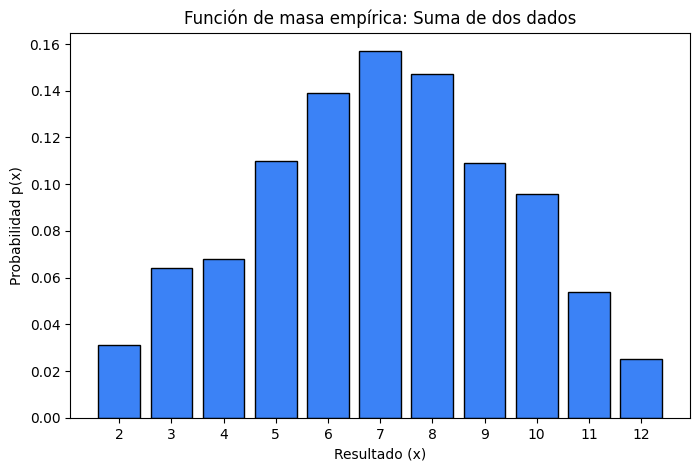

In [ ]:
# -- Versión 1 --
# Definimos el número total de experimentos o simulaciones a realizar (tamaño de la muestra)
N = 1000

# La función np.random.randint(low, high) genera un números enteros aleatorio.
# El límite inferior ('low') es inclusivo, mientras que el límite superior ('high') es exclusivo.
# Todos los números tienen la misma probabilidad de ocurrir.
# Por lo tanto, para simular un dado de 6 caras, los límites son 1 y 7.

# Para ver 'randint' en funcionamiento, simulemos el lanzamiento de 1 dado:
# Nota: cada vez que se ejecute el código, el resultado de 'randint' cambiará
dado1 = np.random.randint(1,7)
print(f'El dado cayó en {dado1}')

# Simulamos el lanzamiento de los 2 dados N veces
resultados = []
for prueba in range(N):
  dado1 = np.random.randint(1,7)
  dado2 = np.random.randint(1,7)
  suma = dado1 + dado2
  resultados.append(suma)

# La función np.unique() identifica los valores únicos presentes en un arreglo.
# Al establecer 'return_counts=True', la función también devuelve la frecuencia absoluta de cada valor.
valores, conteos = np.unique(resultados, return_counts=True)

# Calculamos la frecuencia relativa (probabilidad empírica) dividiendo los conteos entre el total de experimentos.
probabilidades_empiricas = conteos / N

# Inicializamos la figura para el gráfico y definimos sus dimensiones (ancho, alto) en pulgadas.
plt.figure(figsize=(8, 5))

# plt.bar(x, height) genera un diagrama de barras.
# 'x' representa las categorías (valores posibles) y 'height' representa las alturas (probabilidades).
# El parámetro 'edgecolor' añade un contorno a las barras para mejorar la visualización.
plt.bar(valores, probabilidades_empiricas, color='#3b82f6', edgecolor='black')

# Asignamos el título principal y las etiquetas correspondientes a los ejes coordenados.
plt.title('Función de masa empírica: Suma de dos dados')
plt.xlabel('Resultado (x)')
plt.ylabel('Probabilidad p(x)')

# plt.xticks() fuerza explícitamente las marcas en el eje x para asegurar que se muestren todos los números del 2 al 12.
plt.xticks(range(2, 13))

# plt.show() muestra la figura
plt.show()

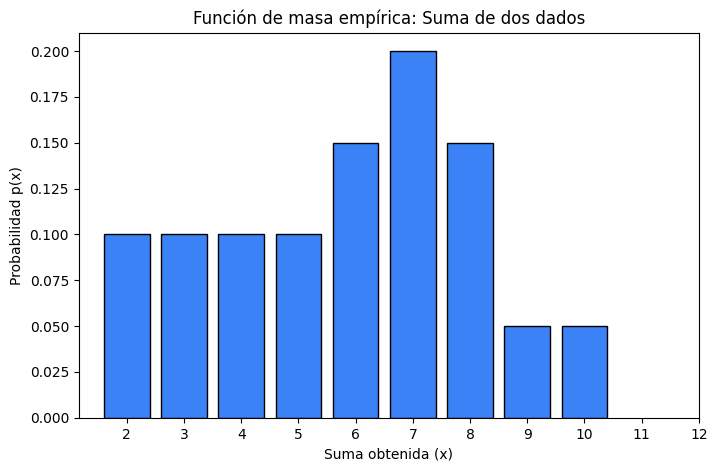

In [ ]:
# -- Versión 2: Optimizada (cambiando el 'for' por operaciones vectoriales) --

N = 20 # Número de experimentos

# Vamos a usar el parámetro 'size' en la función np.random.randint(low, high, size),
# Ahora, la función genera un arreglo de números enteros aleatorios de tamaño 'size'
dado1 = np.random.randint(1, 7, N)
dado2 = np.random.randint(1, 7, N)

# Realizamos la suma de los arreglos elemento a elemento para obtener la variable aleatoria de interés.
suma_dados = dado1 + dado2

# Realizamos el conteo:
valores, conteos = np.unique(suma_dados, return_counts=True)

# Calculamos la frecuencia relativa:
probabilidades_calculadas = conteos / N

# Graficamos:
plt.figure(figsize=(8, 5))

# plt.bar(x, height) genera un diagrama de barras.
# 'x' representa las categorías (valores posibles) y 'height' representa las alturas (probabilidades).
# El parámetro 'edgecolor' añade un contorno a las barras para mejorar la visualización.
plt.bar(valores, probabilidades_calculadas, color='#3b82f6', edgecolor='black')

# Asignamos el título principal y las etiquetas correspondientes a los ejes coordenados.
plt.title('Función de masa empírica: Suma de dos dados')
plt.xlabel('Suma obtenida (x)')
plt.ylabel('Probabilidad p(x)')

# plt.xticks() fuerza explícitamente las marcas en el eje x para asegurar que se muestren todos los números del 2 al 12.
plt.xticks(range(2, 13))

# plt.show() renderiza y despliega la figura generada en la salida de la celda.
plt.show()

**¿Qué sucede si el número de experimentos simulados se reduce mucho?**

Se muestra este error:

*   Desajuste de forma: los objetos no se pueden transmitir a una sola forma. El desajuste se produce entre arg 0 con forma (10,) y arg 1 con forma (11,).

El error ocurre porque np.unique() solo devuelve los valores que realmente aparecieron en los experimentos.Con N lanzamientos muy pequeño, es muy probable que algunas sumas (como el 2 o el 12) no aparezcan ni una sola vez. Entonces valores tendrá menos de 11 elementos (por ejemplo, shape (10,)), pero probabilidades_calculadas tiene shape (11,) por lo que simplemente hay un desajuste.

Cabe destacar que en el código base, se graficas probabilidades_empiricas (de una celda anterior) pero se debe graficar es probabilidades_calculadas en la celda 2 — son variables distintas. Ese es probablemente el bug real.

## 2. Distribución Binomial: Simulación vs. Teoría

La distribución binomial modela la probabilidad de obtener exactamente $x$ "éxitos" en una secuencia de $n$ pruebas independientes, donde cada prueba tiene una probabilidad de éxito constante $a$.

En esta sección, no solo simularemos un proceso binomial, sino que superpondremos la **función de masa teórica** (calculada matemáticamente) sobre nuestra **función de masa empírica** (obtenida por simulación) para analizar qué tanto se aproximan.

**Contexto práctico:** Una campaña de marketing digital envía correos promocionales en lotes de 20 mensajes ($n = 20$). Históricamente, la probabilidad de que un usuario haga clic en el enlace es del 30%. Deseamos analizar la distribución del número de clics obtenidos por lote.

El resultado del experimento de Bernoulli es 0


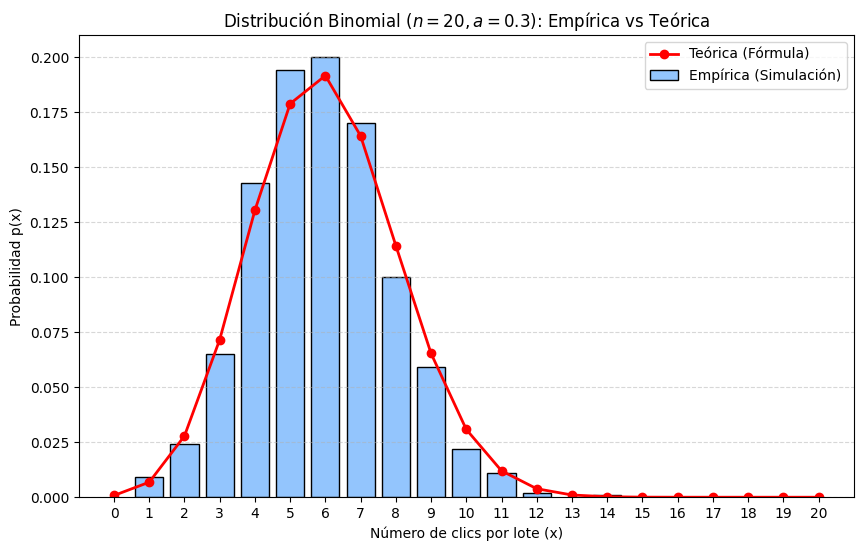

In [ ]:
# Importamos math para calcular el 'número combinatorio', que usaremos para el cálculo teórico de la distribución binomial

# Importamos el módulo 'stats' de SciPy, para probabilidad y estadística en Python.
# Específicamente, importamos 'bernoulli'. Esta función retorna el resultado de un experimento de Bernoulli.
# Un experimento de Bernoulli es una prueba aleatoria con dos resultados posibles:
#"1" ("éxito") con probabilidad a y "0" ("fracaso") con probabilidad (1-a).
# Esto es justo lo que necesitamos para simular una variable aleatoria binomial

import math
from scipy.stats import bernoulli

# Para ver 'bernoulli' en funcionamiento, simulemos el resultado de 1 experimento de Bernoulli.
# Nota: cada vez que se ejecute el código, el resultado de 'randint' cambiará

# bernoulli.rvs(a) ejecuta la prueba de Bernoulli con probabilidad de éxito a
resultado_experimento = bernoulli.rvs(0.5)
print(f'El resultado del experimento de Bernoulli es {resultado_experimento}')

# ==========================================
# 0. EXPERIMENTO BINOMIAL
# ==========================================

# Definimos los parámetros del experimento binomial
n = 20        # Número de correos enviados por lote (n)
a = 0.30     # Probabilidad teórica de clic (a)
N = 1000 # Cantidad de lotes a simular (tamaño de la muestra)

# ==========================================
# 1. CÁLCULO EMPÍRICO (Simulación de Montecarlo)
# ==========================================

clics_simulados = [] # Esta lista almacenará el número de clics por lote
for lote in range(N):
  clics_lote = 0 # Esta variable contará el número de clics en un lote
  for correo in range(n):
    exito = bernoulli.rvs(a) # Simulamos si el usuario hizo o no clic
    clics_lote = clics_lote + exito
  clics_simulados.append(clics_lote)

# Calculamos las frecuencias relativas (probabilidad empírica)
valores_emp, conteos_emp = np.unique(clics_simulados, return_counts=True)
prob_empirica = conteos_emp / N

# ==========================================
# 2. CÁLCULO TEÓRICO
# ==========================================
# np.arange(start, stop) crea un arreglo con todos los valores posibles de x (de 0 a 20 clics).
x_teorico = np.arange(0, n+1)

prob_teorica = [] # Lista donde almacenaremos las probabilidades teóricas de cada valor de x
for x in x_teorico:
  # Evaluamos la fórmula de la función de masa binomial para cada valor de x (clics)
  prob_x = math.comb(n,x)*(a**x)*(1-a)**(n-x) # math.comb(n,x) calcula el número combinatorio de n sobre x
  prob_teorica.append(prob_x)

# ==========================================
# 3. VISUALIZACIÓN COMPARATIVA
# ==========================================
plt.figure(figsize=(10, 6))

# Graficamos la distribución empírica usando un diagrama de barras (azul claro)
plt.bar(valores_emp, prob_empirica, color='#93c5fd', edgecolor='black', label='Empírica (Simulación)')

# Superponemos la distribución teórica usando una línea con marcadores (rojo)
plt.plot(x_teorico, prob_teorica, 'ro-', linewidth=2, markersize=6, label='Teórica (Fórmula)')

# Configuraciones estéticas del gráfico
plt.title(f'Distribución Binomial ($n={n}, a={a}$): Empírica vs Teórica')
plt.xlabel('Número de clics por lote (x)')
plt.ylabel('Probabilidad p(x)')
plt.xticks(range(0, n+1))
plt.legend() # Muestra el cuadro explicativo con las etiquetas (labels)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

---
# Reto 1: Toma de Decisiones Gerenciales bajo Incertidumbre

**Contexto del Negocio:**
Usted es el gerente de análisis de datos de la empresa. Tras revisar los resultados del envío de correos (donde $n=20$ y $a=0.30$), la junta directiva le ha pedido una recomendación para aumentar las ganancias de la campaña promocional.

El departamento de finanzas ha establecido los siguientes parámetros:
* Cada cliente que hace clic en el correo (un "éxito") genera un retorno neto promedio de **$100 USD**.

El equipo de marketing propone dos estrategias alternativas:

* **Estrategia A (Invertir en Calidad):** Contratar a una agencia de diseño para mejorar el contenido del correo. El tamaño del lote se mantiene en $n = 20$ correos, pero el diseño persuasivo aumenta la probabilidad de éxito a $a = 0.60$. El costo total de diseño y envío para este lote "premium" es de **$300 USD**.

* **Estrategia B (Invertir en Volumen):** Mantener el diseño actual con $a = 0.30$, pero adquirir una infraestructura de software masiva que permite enviar lotes más grandes de $n = 50$ correos. El costo operativo de enviar este lote masivo es de **$400 USD**.

**Entregables (mediante Simulaciones de Montecarlo):**
1. Encontrar la **distribución de probabilidad** de clics para cada estrategia.
2. Calcular el **valor esperado** y la **desviación estándar** (raíz cuadrada de la varianza) de clics  para cada estrategia.
3. Encontrar la distribución de probabilidad de la **ganancia** para cada escenario (**ganancia** = **ingresos** - **costos**).
4. Calcular la **ganancia esperada** y su **desviación estándar**.
5. Dar una recomendación sustentada a la gerencia.

**PASO 1. SIMULACIÓN DE MONTECARLO**

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import bernoulli

# ==========================================
# PARÁMETROS GENERALES
# ==========================================
N = 10000           # Tamaño de la simulación (más N = más precisión)
Retorno_Clic = 100  # USD por clic exitoso

# Parámetros de cada estrategia
estrategias = {
    'A': {'n': 20, 'a': 0.60, 'costo': 300, 'label': 'Estrategia A (Calidad, n=20, a=0.60)'},
    'B': {'n': 50, 'a': 0.30, 'costo': 400, 'label': 'Estrategia B (Volumen, n=50, a=0.30)'},
}

# ==========================================
# SIMULACIÓN DE MONTECARLO
# ==========================================
resultados = {}

for nombre, params in estrategias.items():
    n, a, costo = params['n'], params['a'], params['costo']
    clics_simulados = []
    for lote in range(N): # se realiza N veces la simulación
        clics_lote = sum(bernoulli.rvs(a) for _ in range(n))
        clics_simulados.append(clics_lote)
    clics_simulados = np.array(clics_simulados)
    # ==========================================
    # 1. Distribución de probabilidad (probabilidad empírica)
    # ==========================================
    valores_emp, conteos_emp = np.unique(clics_simulados, return_counts=True)
    prob_empirica = conteos_emp / N
    # ==========================================
    # 2. Valor Clic esperado y Desviación estándar
    # ==========================================
    E_clics_emp  = clics_simulados.mean() # numpy calcula el promedio de los 10,000 valores simulados
    Std_clics_emp = clics_simulados.std() # numpy calcula la desviación estándar de los 10,000 valores simulados
    # ==========================================
    # 3. Distribución de probabilidad de la ganancia
    # ==========================================
    ganancias = clics_simulados * Retorno_Clic - costo
    # ==========================================
    # 4. Valor Ganancia esperado y Desviación estándar
    # ==========================================
    E_gan_emp   = ganancias.mean()   # promedio de las 10,000 ganancias simuladas
    Std_gan_emp = ganancias.std()    # dispersión de las 10,000 ganancias simuladas

    resultados[nombre] = {
    # --- Simulación raw ---
    'clics_por_lote':           clics_simulados,   # array de 10,000 resultados simulados
    # --- Distribución empírica de clics ---
    'clics_posibles':           valores_emp,        # qué valores de clics ocurrieron (eje X)
    'prob_de_cada_clic':        prob_empirica,      # con qué frecuencia ocurrió cada uno (eje Y)
    # --- Estadísticas de clics ---
    'valor_esperado_clics':     E_clics_emp,        # promedio de clics por lote
    'desv_std_clics':           Std_clics_emp,      # dispersión de clics por lote
    # --- Ganancias ---
    'ganancias_por_lote':       ganancias,          # array de 10,000 ganancias simuladas
    # --- Estadísticas de ganancias ---
    'valor_esperado_ganancias': E_gan_emp,          # promedio de ganancias por lote
    'desv_std_ganancias':       Std_gan_emp,        # dispersión de ganancias por lote
}


**PASO 2. MOSTRAR RESULTADOS Y GRAFICAS**

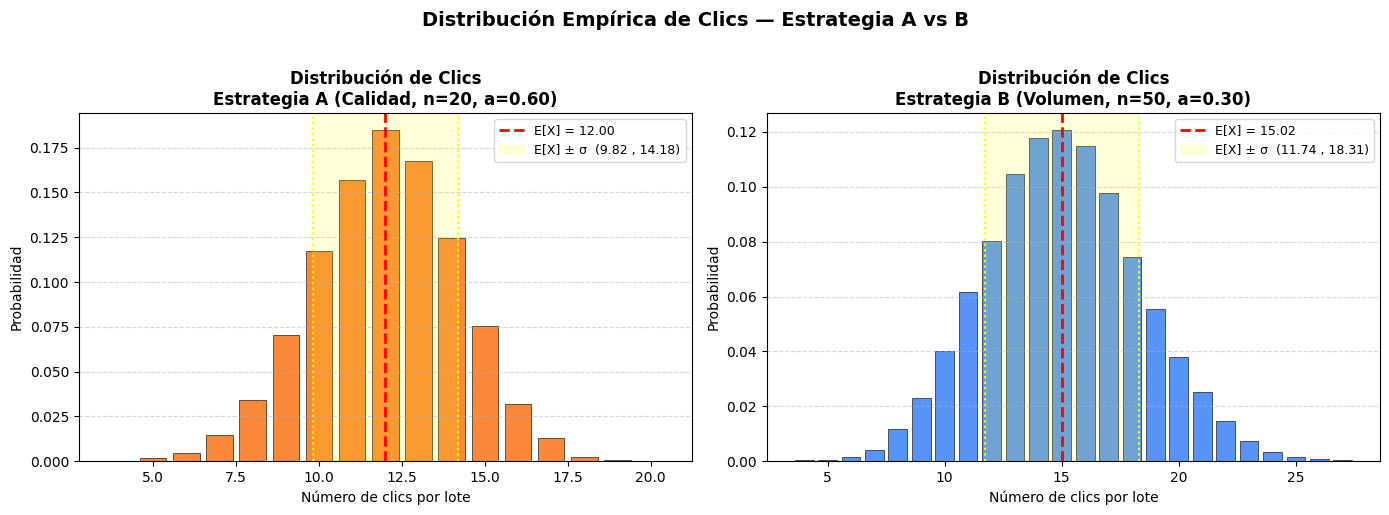


   ANÁLISIS ESTADÍSTICO - SIMULACIÓN DE MONTECARLO
   N = 10,000 lotes simulados

  ESTRATEGIA A — Estrategia A (Calidad, n=20, a=0.60)
  ──────────────────────────────────────────────────────
  CLICS POR LOTE:
    Valor Esperado E[X]  = 11.9991 clics
    Desviación Estándar  = 2.1772 clics
  GANANCIAS POR LOTE:
    Valor Esperado E[G]  = $899.91
    Desviación Estándar  = $217.72
    Ganancia Mínima      = $100.00
    Ganancia Máxima      = $1700.00

  ESTRATEGIA B — Estrategia B (Volumen, n=50, a=0.30)
  ──────────────────────────────────────────────────────
  CLICS POR LOTE:
    Valor Esperado E[X]  = 15.0247 clics
    Desviación Estándar  = 3.2859 clics
  GANANCIAS POR LOTE:
    Valor Esperado E[G]  = $1102.47
    Desviación Estándar  = $328.59
    Ganancia Mínima      = $0.00
    Ganancia Máxima      = $2300.00


  COMPARATIVA ENTRE ESTRATEGIAS
  ──────────────────────────────────────────────────────
  Criterio                      Estrat. A   Estrat. B
  ────────────────────────

In [ ]:
# ==========================================
# GRÁFICO: Distribución de Clics por Estrategia
# ==========================================
fig, (ax_A, ax_B) = plt.subplots(1, 2, figsize=(14, 5))

colores = {'A': '#f97316', 'B': '#3b82f6'}
ejes    = {'A': ax_A,      'B': ax_B}

for nombre, params in estrategias.items():
    r     = resultados[nombre]
    ax    = ejes[nombre]
    color = colores[nombre]

    E   = r['valor_esperado_clics']
    std = r['desv_std_clics']

    # --- Barras empíricas ---
    ax.bar(r['clics_posibles'], r['prob_de_cada_clic'],
           color=color, edgecolor='black', linewidth=0.5, alpha=0.85)

    # --- Línea del valor esperado E[X] ---
    ax.axvline(E, color='red', linewidth=2, linestyle='--',
               label=f"E[X] = {E:.2f}")

    # --- Intervalo E[X] ± σ  (zona sombreada) ---
    ax.axvspan(E - std, E + std, color='yellow', alpha=0.15,
               label=f"E[X] ± σ  ({E-std:.2f} , {E+std:.2f})")

    # --- Líneas de los bordes del intervalo ---
    ax.axvline(E - std, color='yellow', linewidth=1.5, linestyle=':')
    ax.axvline(E + std, color='yellow', linewidth=1.5, linestyle=':')

    # --- Configuración estética ---
    ax.set_title(f"Distribución de Clics\n{params['label'].replace(chr(10), ' ')}",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Número de clics por lote', fontsize=10)
    ax.set_ylabel('Probabilidad', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Distribución Empírica de Clics — Estrategia A vs B',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
# ==========================================
# MOSTRAR RESULTADOS
# ==========================================
print("\n" +"=" * 58)
print("   ANÁLISIS ESTADÍSTICO - SIMULACIÓN DE MONTECARLO")
print(f"   N = {N:,} lotes simulados")
print("=" * 58)

for nombre, params in estrategias.items():
    r = resultados[nombre]

    print(f"\n  ESTRATEGIA {nombre} — {params['label']}")
    print(f"  {'─' * 54}")

    # --- Estadísticas de Clics ---
    print(f"  CLICS POR LOTE:")
    print(f"    Valor Esperado E[X]  = {r['valor_esperado_clics']:.4f} clics")
    print(f"    Desviación Estándar  = {r['desv_std_clics']:.4f} clics")

    # --- Estadísticas de Ganancias ---
    print(f"  GANANCIAS POR LOTE:")
    print(f"    Valor Esperado E[G]  = ${r['valor_esperado_ganancias']:.2f}")
    print(f"    Desviación Estándar  = ${r['desv_std_ganancias']:.2f}")
    print(f"    Ganancia Mínima      = ${r['ganancias_por_lote'].min():.2f}")
    print(f"    Ganancia Máxima      = ${r['ganancias_por_lote'].max():.2f}")

print("\n" + "=" * 58)

# --- Tabla comparativa final ---
rA = resultados['A']
rB = resultados['B']

eA  = rA['valor_esperado_clics']
eB  = rB['valor_esperado_clics']
sA  = rA['desv_std_clics']
sB  = rB['desv_std_clics']
egA = rA['valor_esperado_ganancias']
egB = rB['valor_esperado_ganancias']
sgA = rA['desv_std_ganancias']
sgB = rB['desv_std_ganancias']
ppA = np.mean(rA['ganancias_por_lote'] < 0) * 100
ppB = np.mean(rB['ganancias_por_lote'] < 0) * 100

print("\n  COMPARATIVA ENTRE ESTRATEGIAS")
print(f"  {'─' * 54}")
print(f"  {'Criterio':<28} {'Estrat. A':>10}  {'Estrat. B':>10}")
print(f"  {'─' * 54}")
print(f"  {'E[Clics]':<28} {eA:>10.2f}  {eB:>10.2f}")
print(f"  {'σ Clics':<28} {sA:>10.2f}  {sB:>10.2f}")
print(f"  {'E[Ganancia]':<28} {'$'+f'{egA:.2f}':>10}  {'$'+f'{egB:.2f}':>10}")
print(f"  {'σ Ganancia':<28} {'$'+f'{sgA:.2f}':>10}  {'$'+f'{sgB:.2f}':>10}")
print(f"  {'─' * 54}")

**RESPUESTA:** A partir de los resultados arrojados por la  Simulaciones de Montecarlo, tras simular 10,000 lotes, la Estrategia B (Volumen) es la recomendada frente a la Estrategia A (Calidad). Si bien la Estrategia A mejora la tasa de conversión al 60%, su reducido tamaño de lote (n=20) limita el alcance, generando en promedio 12 clics y una ganancia esperada de  \$ 900 por lote. La Estrategia B, en cambio, al ampliar el lote a 50 correos logra 15 clics en promedio, traducidos en \$1,100 de ganancia esperada, superando a la Estrategia A en \$200 por lote con apenas \$100 adicionales de costo operativo. Esta ventaja se mantiene consistentemente a lo largo de la simulación, lo que la convierte en la opción más rentable y escalable.

**Se recomienda a gerencia invertir en Infraestructura de Volumen como la decisión financieramente más sólida para la campaña.**

# Reto 2: Otras Distribuciones de Probabilidad Típicas

Aparte de la distribución binomial, existen otras distribuciones de probabilidad típicas. Por ejemplo, la distribución geométrica modela el número de ensayos (de Bernoulli) necesarios para obtener el **primer ''éxito''**. A diferencia de la distribución binomial (donde el número de ensayos $n$ es fijo), en la geométrica, la variable aleatoria es el número de ensayos.

**Contexto Práctico (Análisis de Riesgo en la Aviación):**
El miedo a volar es común, pero el análisis de datos nos permite cuantificar el riesgo real. Supongamos que la probabilidad de que un vuelo comercial experimente un "incidente aéreo" (definido como turbulencia severa, fallas mecánicas que obligan a un aterrizaje de emergencia o problemas de presurización) es del $1\%$ (estamos siendo fatalistas, en realidad esta probabilidad es mucho más baja).

La variable aleatoria $X$ representa el **número de vuelos que una persona debe tomar hasta experimentar su primer incidente aéreo**.

**Entregables del Reto:**
1. Simule la experiencia de 10,000 viajeros frecuentes (es posible que necesite usar un ciclo `while` puesto que el viaje en el que ocurre el incidente se desconoce de antemano).
2. A partir de las simulaciones, calcule la distribución del número de vuelos que un pasajero debe realizar hasta que experimenta su primer incidente. Luego, compárela gráficamente con la función de masa teórica de la distribución geométrica (la cual debe consultar).

**Nota 1:** Para las gráficas, es conveniente agrupar $x$ en intervalos (ej. de 0 a 9 vuelos, de 10 a 19 vuelos, etc.). Si no se hace esto, la gráfica tendrá muchísimas barras y será difícil de interpretar.

**Nota 2:** la probabilidad de que ocurra un evento grave en un vuelo es de alrededor de 1 en 5 millones. Muchísimo más baja que el supuesto de nuestro problema didáctico. Si hiciéramos la simulación con este dato real, ¿cuál sería el principal inconveniente?

In [ ]:
# PREGUNTA: Si usáramos a = 1/5,000,000, ¿cuál sería el principal inconveniente?

# RESPUESTA:
a_real  = 1 / 5_000_000
E_X_real = 1 / a_real

print("=" * 55)
print("  ANÁLISIS: PROBABILIDAD REAL DE INCIDENTE")
print("=" * 55)
print(f"\n  Probabilidad real    : {a_real}")
print(f"  E[X] real            : {E_X_real:,.0f} vuelos")
print(f"\n  Si simulamos N=10,000 viajeros:")
print(f"  Cada viajero necesita en promedio {E_X_real:,.0f} vuelos")
print(f"  Total de vuelos a simular ≈ {N * E_X_real:,.0f}")
print("=" * 55)

  ANÁLISIS: PROBABILIDAD REAL DE INCIDENTE

  Probabilidad real    : 2e-07
  E[X] real            : 5,000,000 vuelos

  Si simulamos N=10,000 viajeros:
  Cada viajero necesita en promedio 5,000,000 vuelos
  Total de vuelos a simular ≈ 50,000,000,000


**RESPUESA:** El principal inconveniente es un problema de inviabilidad computacional: la simulación de Montecarlo se vuelve extremadamente lenta cuando la probabilidad del evento es muy pequeña, porque el while debe ejecutarse millones de veces antes de encontrar un éxito. A este problema se le conoce como simulación de eventos raros, y requiere técnicas especiales como el muestreo por importancia para resolverse eficientemente.

**PASO 1. SIMULACIÓN DE MONTECARLO**

In [ ]:
# --- CÓDIGO PROBLEMA DISTRIBUCIÓN GEOMÉTRICA ---
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import bernoulli

# ==========================================
# PARÁMETROS GENERALES
# ==========================================
N = 10000   # Número de viajeros a simular
a = 0.01    # Probabilidad de incidente por vuelo (1%)

# ==========================================
# 1. SIMULACIÓN DE MONTECARLO
# ==========================================
vuelos_hasta_incidente = []  # guardará el resultado de cada viajero

for viajero in range(N):
    vuelos = 0               # contador de vuelos de este viajero
    while True:
        vuelos += 1                      # toma un vuelo
        if bernoulli.rvs(a) == 1:        # ¿ocurrió el incidente?
            break                        # sí → para de volar
    vuelos_hasta_incidente.append(vuelos)

vuelos_hasta_incidente = np.array(vuelos_hasta_incidente)
# ==========================================
# 2. DISTRIBUCIÓN EMPÍRICA Y TEÓRICA
# ==========================================

# --- Definimos los intervalos de agrupación ---
ancho_intervalo = 10
max_vuelos      = 500  # límite para graficar

# Creamos los bordes de cada intervalo:
bordes = np.arange(1, max_vuelos + ancho_intervalo, ancho_intervalo) # bordes de los intervalos: [1, 11, 21, 31, ... 501]

# ==========================================
# 2.1 DISTRIBUCIÓN EMPÍRICA
# ==========================================
# --- Se cuenta cuántos viajeros caen en cada intervalo ---
conteos_emp, _ = np.histogram(vuelos_hasta_incidente, bins=bordes) # toma los datos y cuénta cuántos caen dentro de cada intervalo
prob_emp       = conteos_emp / N  # frecuencia relativa de cada intervalo

# ==========================================
# 2.2 DISTRIBUCIÓN TEÓRICA
# ==========================================
# --- Se calcula la probabilidad de cada intervalo con la fórmula geométrica ---
# P(X = x) = (1-a)^(x-1) * a

prob_teo = []
for i in range(len(bordes) - 1): # numero de intervalos
    x_inicio = bordes[i]
    x_fin    = bordes[i + 1]
    # Sumamos la probabilidad de cada x dentro del intervalo
    prob_intervalo = sum(((1 - a) ** (x - 1)) * a for x in range(x_inicio, x_fin))
    prob_teo.append(prob_intervalo)

prob_teo = np.array(prob_teo)
# Centros de cada intervalo (para graficar en el centro de la barra)
centros = (bordes[:-1] + bordes[1:]) / 2


**PASO 2. MOSTRAR RESULTADOS Y GRAFICAS**

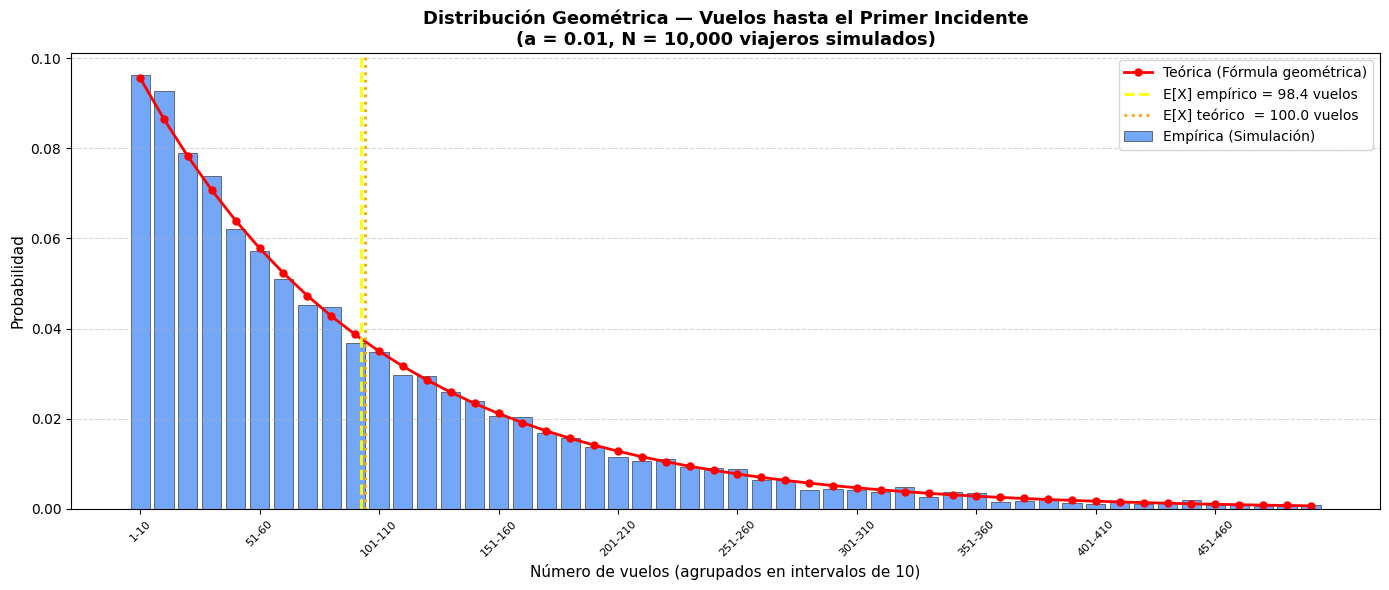

In [ ]:

# ==========================================
# GRÁFICO: Empírico vs Teórico
# ==========================================
fig, ax = plt.subplots(figsize=(14, 6))

# --- Barras empíricas ---
ax.bar(centros, prob_emp, width=ancho_intervalo * 0.8,
       color='#3b82f6', edgecolor='black', linewidth=0.5,
       alpha=0.7, label='Empírica (Simulación)')

# --- Línea teórica ---
ax.plot(centros, prob_teo, 'o-', color='red', linewidth=2,
        markersize=5, label='Teórica (Fórmula geométrica)')

# --- Valor esperado empírico y teórico ---
E_emp = vuelos_hasta_incidente.mean()
E_teo = 1 / a
ax.axvline(E_emp, color='yellow', linewidth=2, linestyle='--',
           label=f"E[X] empírico = {E_emp:.1f} vuelos")
ax.axvline(E_teo, color='orange', linewidth=2, linestyle=':',
           label=f"E[X] teórico  = {E_teo:.1f} vuelos")
# --- Etiquetas del eje X mostrando el rango real de cada barra ---
etiquetas = [f"{bordes[i]}-{bordes[i+1]-1}" for i in range(0, len(bordes)-1, 5)]
posiciones = centros[::5]
ax.set_xticks(posiciones)
ax.set_xticklabels(etiquetas, rotation=45, fontsize=8)
# --- Estética ---
ax.set_title(f'Distribución Geométrica — Vuelos hasta el Primer Incidente\n'
             f'(a = {a}, N = {N:,} viajeros simulados)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Número de vuelos (agrupados en intervalos de 10)', fontsize=11)
ax.set_ylabel('Probabilidad', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# PREGUNTA: Si un pasajero ha viajado 100 veces sin problema,
# ¿cuál es la probabilidad de que su siguiente vuelo sufra un incidente?

# RESPUESTA:
# La probabilidad es exactamente a = 0.01 (1%)
# Esto se debe a la propiedad de FALTA DE MEMORIA de la distribución geométrica:
# el historial de vuelos anteriores NO afecta la probabilidad del siguiente vuelo.
# Cada vuelo es un experimento de Bernoulli INDEPENDIENTE.

# Matemáticamente:
# P(X = 101 | X > 100) = P(X = 1) = a = 0.01

print("=" * 55)
print("  PROPIEDAD DE FALTA DE MEMORIA")
print("=" * 55)
print(f"\n  Vuelos previos sin incidente : 100")
print(f"  P(incidente en vuelo 101)    : {a:.2%}")
print(f"  P(incidente en vuelo   1)    : {a:.2%}")
print(f"\n  → Ambas probabilidades son IGUALES.")
print(f"  → El historial pasado no tiene ningún efecto.")
print("=" * 55)

  PROPIEDAD DE FALTA DE MEMORIA

  Vuelos previos sin incidente : 100
  P(incidente en vuelo 101)    : 1.00%
  P(incidente en vuelo   1)    : 1.00%

  → Ambas probabilidades son IGUALES.
  → El historial pasado no tiene ningún efecto.


**REPUESTA PREGUNTA:** Cada vuelo es un experimento de Bernoulli independiente, por ende la probabilidad es exactamente a = 0.01 (1%). El avión no tiene memoria de cuántos vuelos anteriores tuvo sin incidente. Es exactamente igual al lanzamiento de una moneda:
si sacaste 100 caras seguidas, la probabilidad de la siguiente sigue siendo 50%.

Esto contrasta con la intuición humana, que tiende a pensar "ya llevo muchos vuelos sin problema, algo malo me tiene que pasar pronto". Ese razonamiento erróneo se conoce como la **Falacia del Jugador**.


# Reto 3: Verificación Empírica de Distribuciones (Ingeniería IoT)

En la práctica de la Ciencia de Datos, rara vez conocemos la distribución matemática exacta de un fenómeno por adelantado. Por lo general, recibimos un conjunto de datos en bruto y debemos "verificar" si se ajustan a un modelo teórico conocido.

**Contexto del Problema (Sistema Heredado):**
Una empresa agroindustrial cuenta con una red de sensores inalámbricos desplegada en un cultivo. El sistema es un proyecto heredado (legacy) del cual **se ha perdido toda la documentación técnica**. La empresa no sabe cuántos sensores hay instalados en total en el campo, ni conoce la probabilidad de falla de los equipos.

El único dato disponible es un archivo de registro (log) extraído del servidor central (`df_registro_fallas`), el cual contiene el número de sensores que fallaron y no se conectaron durante cada día, registrado a lo largo de 1.000 días continuos.

El ingeniero principal sospecha que los datos deberían seguir una **Distribución Binomial**.

**Entregable:**
Usted debe comprobar si la hipótesis del ingeniero principal es correcta o no. Para ello, deberá importar los datos, analizarlos y escribir el código necesario para sustentar su conclusión de manera visual. Además, a partir de estos datos debe intentar decifrar cuántos sensores hay instalados y su probabilidad de falla.

In [ ]:
# --- CARGAR DATOS IOT ---

import pandas as pd

# 1. DEFINICIÓN DE LA FUENTE DE DATOS
# ID del archivo donde están las notas:
sheet_id = "1nL1bqEqmuixmvIyZ4i6vK3JwNLk-wnGHKeqbH6RZ2J0"
# Construimos la URL de exportación del archivo (el archivo está disponible en Google Drive):
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv"

# 2. CARGA DEL DataFrame
# Construimos nuestro DataFrame, llamado "df_iot", leyendo el archivo desde la URL:
df_registro_fallas = pd.read_csv(url)

# Veamos cómo es el DataFrame que acabamos de descargar:
display(df_registro_fallas)

,dia_operacion,fallas_conexion
0,1,7
1,2,12
2,3,9
3,4,8
4,5,5
...,...,...
995,996,4
996,997,11
997,998,5
998,999,12


ANÁLISIS DE DISTRIBUCIÓN - SISTEMA IoT AGROINDUSTRIAL

Total de días registrados : 1000
Mín. fallas en un día     : 2
Máx. fallas en un día     : 17
Rango de fallas           : 2 a 17

Media empírica    (μ) : 7.4230
Varianza empírica (σ²)  : 6.3164
Desv. est. empírica     : 2.5132

PARÁMETROS ESTIMADOS (Método de Momentos)
Número total de sensores      n = 50
Probabilidad de falla         p = 0.1485  (14.85 %)
Media teórica           μ = n·p = 7.4230
Varianza teórica σ² = n·p·(1-p) = 6.3210


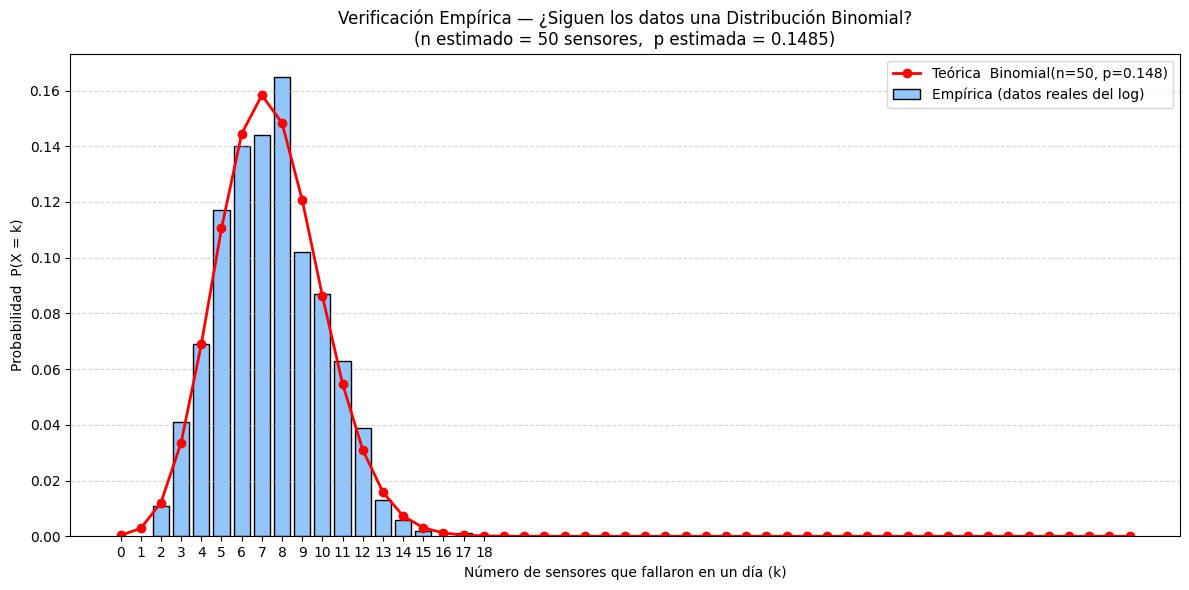

In [ ]:
# --- CÓDIGO PROBLEMA IOT ---

# ==========================================
# 0. IMPORTAR LIBRERIAS
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import binom, chisquare
from scipy.special import comb

# ==========================================
# 1. PREPARACIÓN DE DATOS
# ==========================================
N = len(df_registro_fallas)
Sensores_fallaron = np.array(df_registro_fallas.iloc[:, 1])

print("=" * 60)
print("ANÁLISIS DE DISTRIBUCIÓN - SISTEMA IoT AGROINDUSTRIAL")
print("=" * 60)
print(f"\nTotal de días registrados : {N}")
print(f"Mín. fallas en un día     : {Sensores_fallaron.min()}")
print(f"Máx. fallas en un día     : {Sensores_fallaron.max()}")
print(f"Rango de fallas           : {Sensores_fallaron.min()} a {Sensores_fallaron.max()}")

# ==========================================
# 2. ESTADÍSTICAS EMPÍRICAS
# ==========================================
media_emp = np.mean(Sensores_fallaron)          # media empirica (μ)
var_emp   = np.var(Sensores_fallaron, ddof=1)   # varianza muestral (σ²)
std_emp   = np.std(Sensores_fallaron,  ddof=1)  # desviación estandar empirica

print(f"\nMedia empírica    (μ) : {media_emp:.4f}")
print(f"Varianza empírica (σ²)  : {var_emp:.4f}")
print(f"Desv. est. empírica     : {std_emp:.4f}")

# ==========================================
# 2.1 DISTRIBUCIÓN EMPÍRICA
# ==========================================
# np.unique nos devuelve cada valor único que aparece en los datos,
# junto con cuántas veces aparece (conteos).
# Dividimos los conteos entre N para obtener frecuencias relativas (probabilidad empírica).

valores_emp, conteos_emp = np.unique(sensores_fallaron, return_counts=True)
prob_empirica            = conteos_emp / N

# ==========================================
# 3. ESTIMACIÓN DE PARÁMETROS (Método de Momentos)
# ==========================================
#    Si los datos siguen una Binomial(n, p), sabemos que:
#    Método de Momentos:
#    σ² = n·p·(1−p)    →  p = 1 − (σ²/μ)
#    μ  = n·p          →  n = μ / p
#    donde :
#          μ: media
#          σ²: varianza
#          n: número de ensayos
#          p: probabilidad de exito
# ==========================================
p_est = 1 - (var_emp / media_emp)
n_est = int(round(media_emp / p_est))
# Reajustamos p con n entero para que sea consistente
p_est = media_emp / n_est

print("\n" + "=" * 60)
print("PARÁMETROS ESTIMADOS (Método de Momentos)")
print("=" * 60)
print(f"Número total de sensores      n = {n_est}")
print(f"Probabilidad de falla         p = {p_est_fino:.4f}  ({p_est_fino*100:.2f} %)")
print(f"Media teórica           μ = n·p = {n_est * p_est_fino:.4f}")
print(f"Varianza teórica σ² = n·p·(1-p) = {n_est * p_est_fino * (1 - p_est_fino):.4f}")


# ==========================================
# 4. DISTRIBUCIÓN TEÓRICA BINOMIAL
# ==========================================
# Con n y p estimados, calculamos la probabilidad teórica para cada
# valor posible de k (de 0 a n) usando la fórmula de la PMF binomial:
#   P(X = k) = C(n, k) * p^k * (1-p)^(n-k)

x_teorico    = np.arange(0, n_est + 1)   # Todos los valores posibles de k
prob_teorica = []

for k in x_teorico:
    prob_k = math.comb(n_est, k) * (p_est ** k) * ((1 - p_est) ** (n_est - k))
    prob_teorica.append(prob_k)

# ==========================================
# 5. VISUALIZACIÓN COMPARATIVA
# ==========================================

plt.figure(figsize=(12, 6))

# Distribución empírica: barras con las frecuencias relativas observadas
plt.bar(valores_emp, prob_empirica,
        color='#93c5fd', edgecolor='black',
        label='Empírica (datos reales del log)')

# Distribución teórica: línea con marcadores sobre las barras
plt.plot(x_teorico, prob_teorica,
         'ro-', linewidth=2, markersize=6,
         label=f'Teórica  Binomial(n={n_est}, p={p_est:.3f})')

# Configuración estética
plt.title(f'Verificación Empírica — ¿Siguen los datos una Distribución Binomial?\n'
          f'(n estimado = {n_est} sensores,  p estimada = {p_est:.4f})')
plt.xlabel('Número de sensores que fallaron en un día (k)')
plt.ylabel('Probabilidad  P(X = k)')
plt.xticks(range(0, sensores_fallaron.max() + 2))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Días registrados : 1000
Mínimo de fallas : 2
Máximo de fallas : 17

--- Parámetros estimados ---
Número de sensores instalados (n) : 50
Probabilidad de falla       (p)   : 0.1485  (14.85%)


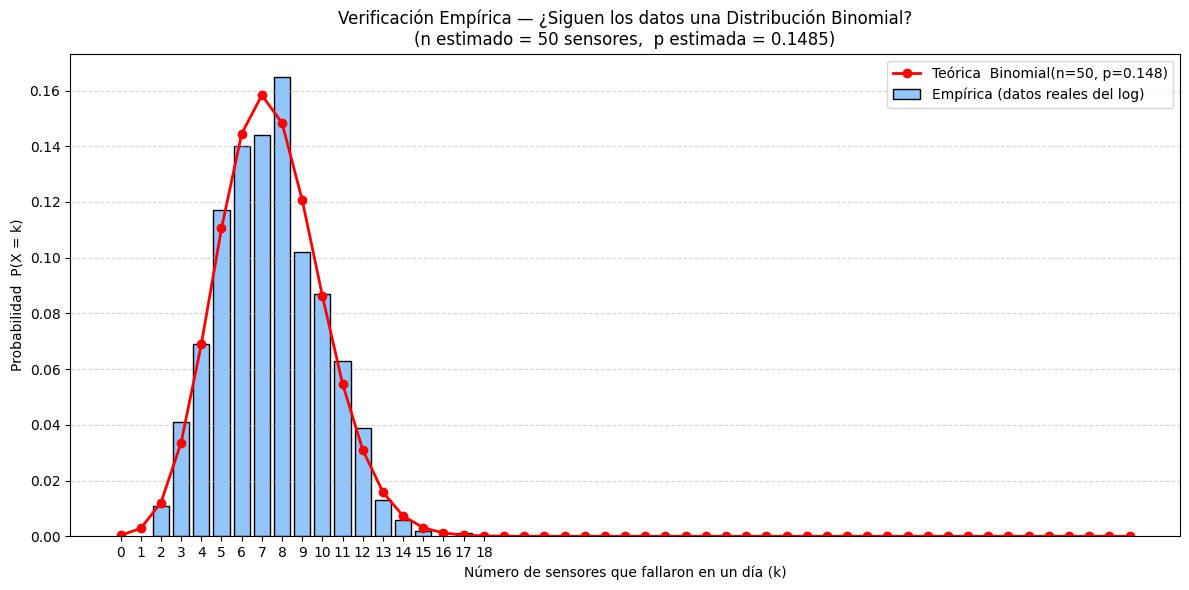


--- Conclusión ---
La curva teórica Binomial(n=50, p=0.1485) se superpone
estrechamente sobre las barras empíricas.
→ La hipótesis del ingeniero es CORRECTA:
  Los datos siguen una Distribución Binomial.

Interpretación del sistema heredado:
  · Hay aproximadamente 50 sensores instalados en el cultivo.
  · Cada sensor tiene un 14.85% de probabilidad de fallar cada día.


In [ ]:
# ==========================================
# RETO 3: VERIFICACIÓN EMPÍRICA DE DISTRIBUCIONES
# ==========================================

import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli

# ==========================================
# 1. CARGA DE DATOS
# ==========================================

import pandas as pd

sheet_id = "1nL1bqEqmuixmvIyZ4i6vK3JwNLk-wnGHKeqbH6RZ2J0"
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv"
df_registro_fallas = pd.read_csv(url)

# Extraemos la columna de fallas como arreglo numérico
N                = len(df_registro_fallas)          # Número de días registrados (1000)
sensores_fallaron = np.array(df_registro_fallas.iloc[:, 1])  # Fallas por día

print(f"Días registrados : {N}")
print(f"Mínimo de fallas : {sensores_fallaron.min()}")
print(f"Máximo de fallas : {sensores_fallaron.max()}")

# ==========================================
# 2. DISTRIBUCIÓN EMPÍRICA
# ==========================================
# np.unique nos devuelve cada valor único que aparece en los datos,
# junto con cuántas veces aparece (conteos).
# Dividimos los conteos entre N para obtener frecuencias relativas (probabilidad empírica).

valores_emp, conteos_emp = np.unique(sensores_fallaron, return_counts=True)
prob_empirica            = conteos_emp / N

# ==========================================
# 3. ESTIMACIÓN DE PARÁMETROS (Método de Momentos)
# ==========================================
# Si los datos siguen una Binomial(n, p), sabemos que:
#   Media    μ  = n * p
#   Varianza σ² = n * p * (1 - p)
#
# Dividiendo σ²/μ = (1 - p), podemos despejar:
#   p = 1 - (σ² / μ)
#   n = round(μ / p)

media_emp = np.mean(sensores_fallaron)
var_emp   = np.var(sensores_fallaron, ddof=1)   # ddof=1 → varianza muestral

p_est = 1 - (var_emp / media_emp)               # Probabilidad de falla estimada
n_est = int(round(media_emp / p_est))           # Número de sensores estimado

# Reajustamos p con n entero para que sea consistente
p_est = media_emp / n_est

print(f"\n--- Parámetros estimados ---")
print(f"Número de sensores instalados (n) : {n_est}")
print(f"Probabilidad de falla       (p)   : {p_est:.4f}  ({p_est*100:.2f}%)")

# ==========================================
# 4. DISTRIBUCIÓN TEÓRICA BINOMIAL
# ==========================================
# Con n y p estimados, calculamos la probabilidad teórica para cada
# valor posible de k (de 0 a n) usando la fórmula de la PMF binomial:
#   P(X = k) = C(n, k) * p^k * (1-p)^(n-k)

x_teorico    = np.arange(0, n_est + 1)   # Todos los valores posibles de k
prob_teorica = []

for x in x_teorico:
    prob_x = math.comb(n_est, x) * (p_est ** x) * ((1 - p_est) ** (n_est - x))
    prob_teorica.append(prob_x)

# ==========================================
# 5. VISUALIZACIÓN COMPARATIVA
# ==========================================

plt.figure(figsize=(12, 6))

# Distribución empírica: barras con las frecuencias relativas observadas
plt.bar(valores_emp, prob_empirica,
        color='#93c5fd', edgecolor='black',
        label='Empírica (datos reales del log)')

# Distribución teórica: línea con marcadores sobre las barras
plt.plot(x_teorico, prob_teorica,
         'ro-', linewidth=2, markersize=6,
         label=f'Teórica  Binomial(n={n_est}, p={p_est:.3f})')

# Configuración estética
plt.title(f'Verificación Empírica — ¿Siguen los datos una Distribución Binomial?\n'
          f'(n estimado = {n_est} sensores,  p estimada = {p_est:.4f})')
plt.xlabel('Número de sensores que fallaron en un día (k)')
plt.ylabel('Probabilidad  P(X = k)')
plt.xticks(range(0, sensores_fallaron.max() + 2))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ==========================================
# 6. CONCLUSIÓN
# ==========================================
print("\n--- Conclusión ---")
print(f"La curva teórica Binomial(n={n_est}, p={p_est:.4f}) se superpone")
print(f"estrechamente sobre las barras empíricas.")
print(f"→ La hipótesis del ingeniero es CORRECTA:")
print(f"  Los datos siguen una Distribución Binomial.")
print(f"\nInterpretación del sistema heredado:")
print(f"  · Hay aproximadamente {n_est} sensores instalados en el cultivo.")
print(f"  · Cada sensor tiene un {p_est*100:.2f}% de probabilidad de fallar cada día.")